In [50]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [51]:
train_data = pd.read_csv('Datasets/DailyDelhiClimateTrain.csv', index_col='date', parse_dates=True)
test_data = pd.read_csv('Datasets/DailyDelhiClimateTest.csv', index_col='date', parse_dates=True)

train_values = train_data.values
test_values = test_data.values

T = 7
H = 7
humidity_idx = train_data.columns.get_loc('humidity')

def make_dataset_multistep(values, T, H, humidity_idx):
    X, Y = [], []
    for t in range(len(values) - T - H + 1):
        X.append(values[t:t+T])
        Y.append([values[t+T + h][humidity_idx] for h in range(H)])
    return np.array(X), np.array(Y)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_values)
test_scaled  = scaler.transform(test_values)

X_train, Y_train = make_dataset_multistep(train_scaled, T, H, humidity_idx)
X_test,  Y_test  = make_dataset_multistep(test_scaled,  T, H, humidity_idx)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (1449, 7, 4)
Y_train shape: (1449, 7)


In [52]:
n_features = train_values.shape[1]

lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(T, n_features), return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(H)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, Y_train, epochs=300, batch_size=64, verbose=1)

Epoch 1/300


c:\Users\anton\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8105
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5580
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4541
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4317
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4190
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4114
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4047
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3986
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3951
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3925
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3927
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3875
Epoch 13/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3859
Epoch 14/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3857
Epoch 15/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3802
Epoch 16/300
23/

In [53]:
test_loss = lstm_model.evaluate(X_test, Y_test, batch_size=64, verbose=1)
print("Test Loss (MSE):", test_loss)

def inverse_humidity_multi(preds_scaled, scaler, humidity_idx, n_features):
    n_samples, Hloc = preds_scaled.shape
    preds_orig = np.zeros((n_samples, Hloc))
    for h in range(Hloc):
        tmp = np.zeros((n_samples, n_features))
        tmp[:, humidity_idx] = preds_scaled[:, h]
        inv = scaler.inverse_transform(tmp)
        preds_orig[:, h] = inv[:, humidity_idx]
    return preds_orig

n_features = train_values.shape[1]
n_test_days = test_scaled.shape[0]

history = [row.copy() for row in train_scaled[-T:]]
preds_scaled_list = []

day_idx = 0
while day_idx < n_test_days:
    inp = np.array(history[-T:]).reshape(1, T, n_features)
    block_pred_scaled = lstm_model.predict(inp)[0]
    
    for h in range(H):
        if day_idx >= n_test_days:
            break
        row = test_scaled[day_idx].copy()
        row[humidity_idx] = block_pred_scaled[h]
        history.append(row)
        preds_scaled_list.append(block_pred_scaled[h])
        day_idx += 1

preds_scaled_array = np.array(preds_scaled_list).reshape(-1, 1)
preds_orig = inverse_humidity_multi(preds_scaled_array, scaler, humidity_idx, n_features).ravel()

true_humidity = test_data['humidity'].values

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5363 
Test Loss (MSE): 0.5362672805786133
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


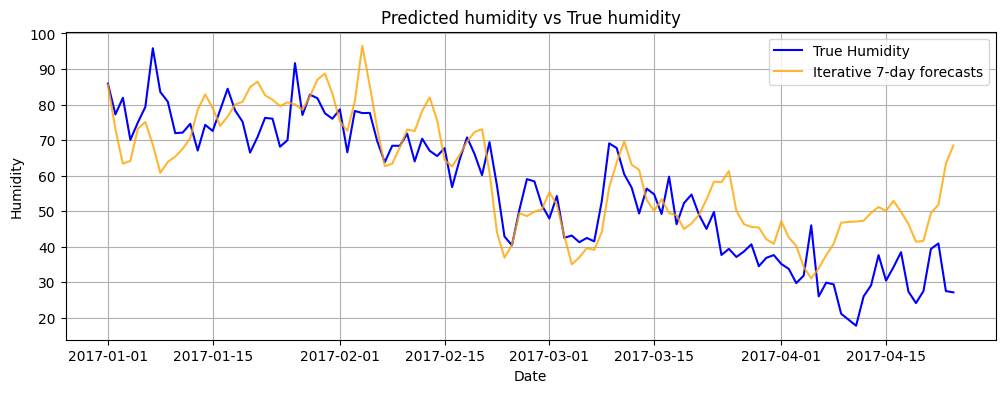

In [54]:
plt.figure(figsize=(12,4))
plt.plot(test_data.index, true_humidity, label='True Humidity', color='blue')
plt.plot(test_data.index, preds_orig, label='Iterative 7-day forecasts', color='orange', alpha=0.8)
plt.title('Predicted humidity vs True humidity')
plt.xlabel('Date')
plt.ylabel('Humidity')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
rmse = np.sqrt(mean_squared_error(true_humidity, preds_orig))
mae  = mean_absolute_error(true_humidity, preds_orig)
print(f"Iterative forecast RMSE: {rmse:.3f}")
print(f"Iterative forecast MAE : {mae:.3f}")


Iterative forecast RMSE: 12.144
Iterative forecast MAE : 9.438
